In [1]:
import numpy as np
import os, tqdm
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import corner

In [2]:
output_stat_dir = '../output'

In [3]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
nparams = len(params)
# parameter values for fiducial simulation
fid = np.array([10**4.7,15,30])

In [4]:
model_files = {}

model_files['PS 1D'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_ps.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_ps.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_ps.txt'),
}

model_files['PS 2D'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_PS2D_no_wedge_updated.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_PS2D_no_wedge_updated.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_PS2D_no_wedge_updated.txt'),
}

In [5]:
# --- Styling Definitions ---
# Define colors for each model type and linestyles for each case
style_guide = {
    'PS 1D': {'color': 'C0', 'label': 'Spherical PS'},
    'PS 2D': {'color': 'C1', 'label': 'Cylindrical PS'}
}

linestyles = {
    'AA* (100 h)': ('-', 'AA* (100 h)'),
    'AA* (1000 h)': ('--', 'AA* (1000 h)'),
    'AA4 (1000 h)': (':', 'AA4 (1000 h)')
}

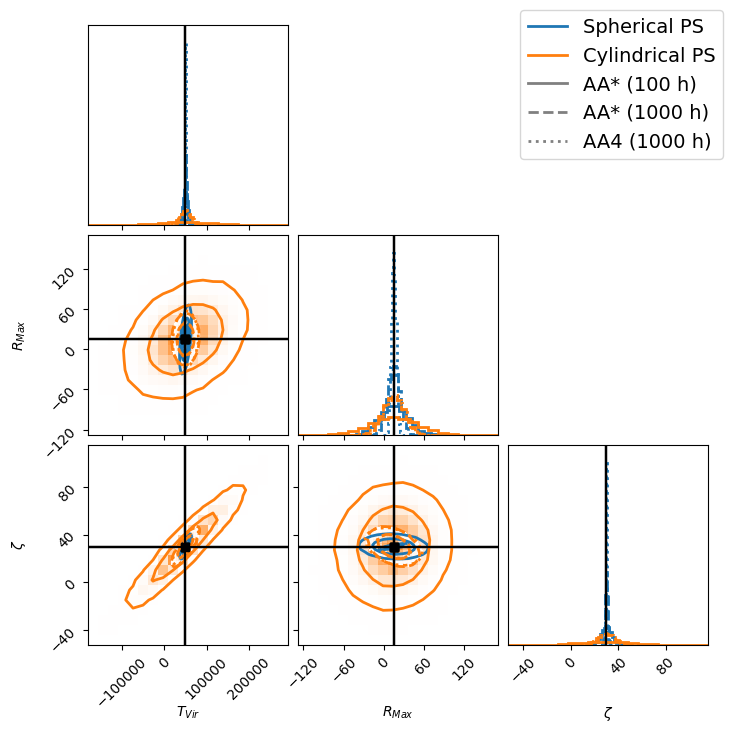

In [ ]:
# --- Plotting ---
n_samples = 100000
fig = None

# Loop through both 'PS 1D' and 'PS 2D' models
for model_type, cases in model_files.items():
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    for case_name, file_path in cases.items():
        linestyle = linestyles[case_name][0]
        
        # Load covariance and generate samples
        cov = np.loadtxt(file_path)
        fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
        
        # Add samples to the corner plot with specified styles
        fig = corner.corner(
            fisher_samples,
            fig=fig,
            labels=Fisher_Param,
            plot_datapoints=False,
            levels=(0.68, 0.95),
            truths=fid,
            truth_color='black',
            color=color, # Base color for the group
            # Apply linestyles to both 1D histograms and 2D contours
            hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
            contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
            range=[],
        )

# --- Create Custom Legend ---
# Create proxy artists for the legend
legend_elements = []

# Add entries for model types (colors)
for model_type, styles in style_guide.items():
    legend_elements.append(mlines.Line2D(
        [], [], color=styles['color'], lw=2, label=styles['label']
    ))
    
# Add entries for observation cases (linestyles)
for case_name, (ls, label) in linestyles.items():
     legend_elements.append(mlines.Line2D(
        [], [], color='gray', lw=2, linestyle=ls, label=label
    ))

# Add the legend to the top-right corner of the figure
fig.legend(handles=legend_elements, loc='upper right', fontsize=14, bbox_to_anchor=(0.98, 0.98))

plt.show()

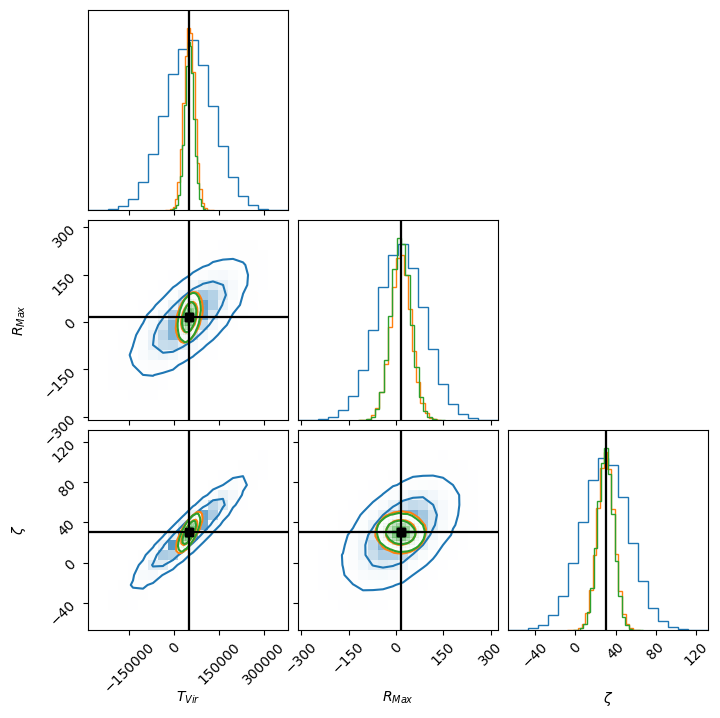

In [6]:
n_samples = 100000
fig = None 
for ii,name in enumerate(model_files['PS 2D'].keys()):
    file = model_files['PS 2D'][name]
    cov = np.loadtxt(file)
    fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
    fig = corner.corner(
            fisher_samples,
            fig=fig,
            labels=Fisher_Param,
            plot_datapoints=False,  
            levels=(0.68,0.95),
            truths=fid,
            truth_color='black', 
            color=f'C{ii}',           
        )

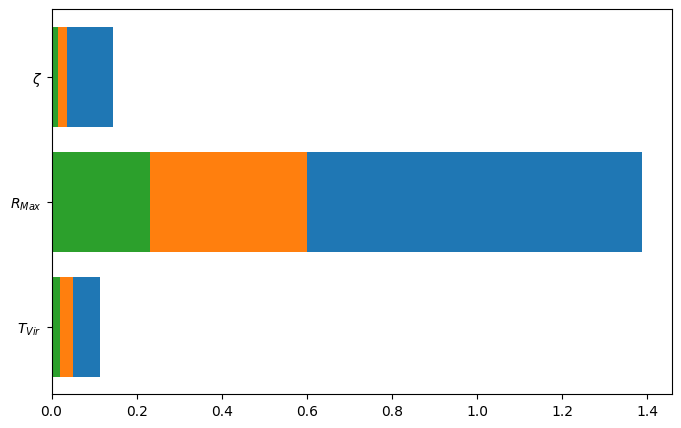

In [19]:
plt.figure(figsize=(8, 5))
sig_normed = np.empty(len(model_files.keys()))
for ii,name in enumerate(model_files.keys()):
    file = model_files[name]
    cov = np.loadtxt(file)
    # sig_normed[ii] = np.diagonal(cov)/fid
    plt.barh(Fisher_Param, np.sqrt(np.diagonal(cov))/fid, color=f'C{ii}')
    